In [19]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# قراءة البيانات
df = pd.read_csv('../data/raw/players_22.csv', low_memory=False)

# عرض نظرة عامة
print(f'📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
display(df.head())
# names of all columns
print(f'📋 Column Names: {df.columns.tolist()}')

📊 Dataset Shape: 19239 rows, 110 columns


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


📋 Column Names: ['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_

In [20]:
selected_columns = ['short_name', 'player_positions', 'age', 'overall', 'potential', 'value_eur']
df_selected = df[selected_columns]
print(f'📊 Selected Dataset Shape: {df_selected.shape[0]} rows, {df_selected.shape[1]} columns')
display(df_selected.head())


📊 Selected Dataset Shape: 19239 rows, 6 columns


,short_name,player_positions,age,overall,potential,value_eur
0,L. Messi,"RW, ST, CF",34,93,93,78000000.0
1,R. Lewandowski,ST,32,92,92,119500000.0
2,Cristiano Ronaldo,"ST, LW",36,91,91,45000000.0
3,Neymar Jr,"LW, CAM",29,91,91,129000000.0
4,K. De Bruyne,"CM, CAM",30,91,91,125500000.0


In [21]:
print("🔍 عدد القيم المفقودة في كل عمود:")
print(df_selected.isnull().sum())
print("-" * 50)

🔍 عدد القيم المفقودة في كل عمود:
short_name           0
player_positions     0
age                  0
overall              0
potential            0
value_eur           74
dtype: int64
--------------------------------------------------


In [22]:
# حذف الصفوف التي تحتوي على قيم مفقودة في العمود الهدف
df_clean = df_selected.dropna(subset=['value_eur']).copy()
print(f'✅ Shape after dropping missing targets: {df_clean.shape}')

✅ Shape after dropping missing targets: (19165, 6)


In [23]:
print(df_clean.isnull().sum())

short_name          0
player_positions    0
age                 0
overall             0
potential           0
value_eur           0
dtype: int64


In [24]:
# فصل القيم المتعددة في العمود إلى أعمدة منفصلة (Multi-Hot Encoding)
encoded_cols = df_clean['player_positions'].str.get_dummies(sep=', ')

# دمج الأعمدة الجديدة مع البيانات الأصلية
df_clean = pd.concat([df_clean, encoded_cols], axis=1)

# حذف العمود النصي القديم
df_clean = df_clean.drop('player_positions', axis=1)

print(f'✅ Shape after Multi-Hot Encoding: {df_clean.shape}')

✅ Shape after Multi-Hot Encoding: (19165, 20)


In [25]:
display(df_clean.head())

,short_name,age,overall,potential,value_eur,CAM,CB,CDM,CF,CM,GK,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
0,L. Messi,34,93,93,78000000.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
1,R. Lewandowski,32,92,92,119500000.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,Cristiano Ronaldo,36,91,91,45000000.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,Neymar Jr,29,91,91,129000000.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,K. De Bruyne,30,91,91,125500000.0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0


📈 مدى ارتباط كل ميزة بسعر اللاعب:
value_eur    1.000000
overall      0.554684
potential    0.527738
CF           0.068834
LW           0.049143
age          0.042886
Name: value_eur, dtype: float64
------------------------------
LWB   -0.000692
LB    -0.018368
CB    -0.022418
RB    -0.024052
GK    -0.042647
Name: value_eur, dtype: float64


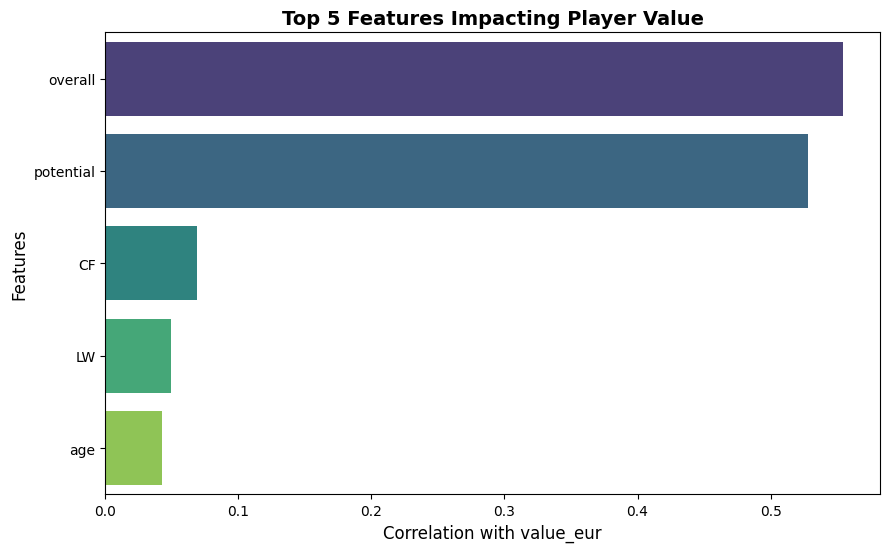

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. هنعزل عمود الاسم عشان دالة الارتباط بتشتغل على الأرقام بس
numeric_df = df_clean.drop(columns=['short_name'])

# 2. حساب الارتباط مع السعر وترتيبه من الأكبر للأصغر
correlations = numeric_df.corr()['value_eur'].sort_values(ascending=False)

print("📈 مدى ارتباط كل ميزة بسعر اللاعب:")
# هنعرض أول 5 (أعلى تأثير إيجابي) وآخر 5 (أعلى تأثير سلبي)
print(correlations.head(6)) 
print("-" * 30)
print(correlations.tail(5))

# 3. رسم بياني لأهم 5 عوامل بتأثر على السعر
plt.figure(figsize=(10, 6))
# استبعدنا أول صف (لأنه ارتباط السعر بنفسه = 1)
sns.barplot(x=correlations.values[1:6], y=correlations.index[1:6], palette='viridis')
plt.title('Top 5 Features Impacting Player Value', fontsize=14, fontweight='bold')
plt.xlabel('Correlation with value_eur', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

In [30]:
df_clean.to_csv('../data/processed/football_players_cleaned.csv', index=False)